# 1.의사결정 트리(Decision Tree) 알고리즘

### 데이터 전처리

*  fruit : 과일 종류 <br>
*  weight : 과일 무게 <br>
*  height : 세로 길이 <br>
*  width : 가로 길이 <br>
*  hardness : 단단한 정도 <br>
*  sweet : 당도 <br>
*  sour : 산도 <br>
*  color : 착색도 <br> 

> 데이터 출처 : 농업 진흥청 국립원예특작과학원 과수생육품질관리시스템 (https://fruit.nihhs.go.kr/)





In [1]:
# 데이터 저장
import pandas as pd
import numpy as np

df = pd.read_excel('사과배복숭아-학습.xlsx')
df

,fruit,weight,height,width,hardness,sweet,sour,color
0,복숭아,310.7,76.2,86.3,45.2,12.7,0.35,60.8
1,복숭아,265.9,74.5,81.8,29.5,14.2,0.24,61.0
2,복숭아,407.5,82.6,90.1,34.1,14.3,0.29,68.2
3,복숭아,314.6,74.5,86.1,22.1,14.9,0.28,62.1
4,복숭아,310.7,77.5,85.7,31.1,13.0,0.40,64.6
...,...,...,...,...,...,...,...,...
163,사과,221.3,73.2,80.0,55.8,10.5,0.31,43.6
164,사과,252.2,71.3,84.3,34.5,13.4,0.40,42.6
165,사과,284.3,78.2,88.0,36.2,13.6,0.36,44.8
166,사과,314.3,77.3,91.1,34.1,12.9,0.35,45.7


In [2]:
# 결측치 값의 유무 확인
df.isna().sum()
# -> color 칼럼에 결측치가 존재

fruit        0
weight       0
height       0
width        0
hardness     0
sweet        0
sour         0
color       49
dtype: int64

In [3]:
# 모든 결측치 값을 0으로 대체
df.fillna(0, inplace=True)
df.isna().sum()

fruit       0
weight      0
height      0
width       0
hardness    0
sweet       0
sour        0
color       0
dtype: int64

### 인코딩

머신 러닝의 원활한 학습을 위해서 문자로 되어있는 fruit(과일 종류) 칼럼의 값을 수치값으로 변경

데이터프레임에 replace 메소드를 사용해서 '사과' --> 0, '배' --> 1, '복숭아' -->  2로 변경 <br>
바꿀 값이 3개 밖에 되지 않기 때문에 가능 : 칼럼이 갖는 값의 개수가 많으면 replace( ) 를 이용하는 것이 불편 <br>
문자로 된 값을 내가 원하는 값으로 바꿀 수 있다는 장점이 있음

In [4]:
# fruit 칼럼의 항목값별 개수 세기
df['fruit'].value_counts()

사과     77
배      49
복숭아    42
Name: fruit, dtype: int64

In [5]:
# fruit 칼럼의 값 변환
df.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)
df

,fruit,weight,height,width,hardness,sweet,sour,color
0,2,310.7,76.2,86.3,45.2,12.7,0.35,60.8
1,2,265.9,74.5,81.8,29.5,14.2,0.24,61.0
2,2,407.5,82.6,90.1,34.1,14.3,0.29,68.2
3,2,314.6,74.5,86.1,22.1,14.9,0.28,62.1
4,2,310.7,77.5,85.7,31.1,13.0,0.40,64.6
...,...,...,...,...,...,...,...,...
163,0,221.3,73.2,80.0,55.8,10.5,0.31,43.6
164,0,252.2,71.3,84.3,34.5,13.4,0.40,42.6
165,0,284.3,78.2,88.0,36.2,13.6,0.36,44.8
166,0,314.3,77.3,91.1,34.1,12.9,0.35,45.7


In [6]:
#과일 종류별 평균값 확인
df.groupby('fruit').mean()

,weight,height,width,hardness,sweet,sour,color
fruit,,,,,,,
0,291.206494,78.167532,87.055844,43.549351,13.903896,0.310000,52.781818
1,617.228571,96.612245,93.832653,33.234694,12.300000,0.208163,0.000000
2,340.166667,79.159524,88.573810,34.238095,12.466667,0.313810,63.019048


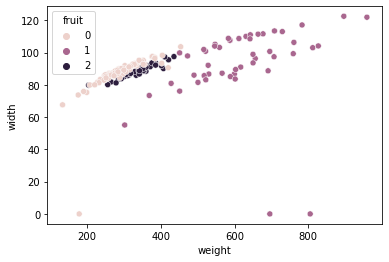

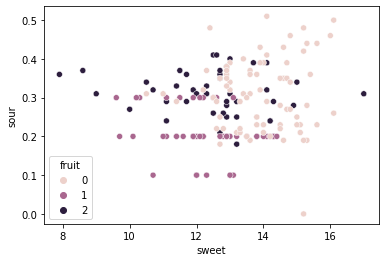

In [7]:
# 그래프로 살펴보기
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(data=df, x='weight', y='width', hue='fruit') 
plt.show()

sns.scatterplot(data=df, x='sweet', y='sour', hue='fruit') 
plt.show()

### 모델 생성 및 학습

In [8]:
#머신 러닝 학습
from sklearn.tree import DecisionTreeClassifier

# 학습용 데이터  
x_train = df.iloc[:, 1:]  # 학습 데이터의 속성값
y_train = df.iloc[:,0]    # 학습 데이터의 정답

#의사 결정트리 알고리즘 모델 객체를 생성
tr_model = DecisionTreeClassifier(random_state=0)
# 학습 데이터를 전달하여 머신러닝모델 완성
tr_model.fit(x_train, y_train)

DecisionTreeClassifier(random_state=0)

In [9]:
#예측하기
new_fruit = pd.DataFrame([[270.0, 75.0, 85.0, 37.0, 13.5, 0.22, 55.0]], 
                         columns = x_train.columns)
tr_model.predict(new_fruit)

array([0], dtype=int64)

### 모델 평가

In [10]:
# 테스트용 데이터 읽어오기
df_test = pd.read_excel('사과배복숭아-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)
df_test

,fruit,weight,height,width,hardness,sweet,sour,color
0,2,400.5,82.6,90.1,32.1,15.3,0.29,68.2
1,2,310.6,73.5,80.1,20.1,15.0,0.28,62.1
2,2,340.0,75.0,86.7,20.5,14.1,0.32,58.4
3,2,330.0,78.8,85.0,41.5,13.0,0.31,58.6
4,1,680.0,100.0,111.6,36.8,12.0,0.10,0.0
5,1,640.0,99.0,96.3,30.1,12.0,0.20,0.0
6,1,599.6,104.1,86.7,31.5,10.1,0.20,0.0
7,0,319.0,87.0,89.2,57.7,13.3,0.21,56.1
8,0,350.0,89.0,91.8,35.0,13.6,0.31,57.8
9,0,270.0,75.0,85.0,37.0,13.3,0.22,55.6


In [11]:
# 예측하기
x_test =  df_test.iloc[:,1:]   # 테스트 데이터의 속성값
y_test =  df_test.iloc[:,0]     # 테스트 데이터의 정답
#생성한 모델을 사용해서 테스트 데이터의 속성값을 이용해 예측값 산출
tr_prd = tr_model.predict(x_test)
tr_prd

array([0, 2, 2, 2, 1, 1, 1, 0, 0, 0], dtype=int64)

In [12]:
#평가하기
from sklearn.metrics import accuracy_score

# 예측값과 테스트 데이터의 정답을 비교해서 정확도 계산
print('정확도 =',accuracy_score(y_test, tr_prd))
# 에측값과 테스트 데이터의 정답을 동시 출력해서 비교
for i in range(len(y_test)):
    print('예측:',tr_prd[i], ' 정답:',y_test.iloc[i])

정확도 = 0.9
예측: 0  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 1  정답: 1
예측: 1  정답: 1
예측: 1  정답: 1
예측: 0  정답: 0
예측: 0  정답: 0
예측: 0  정답: 0


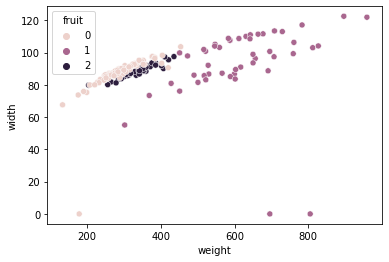

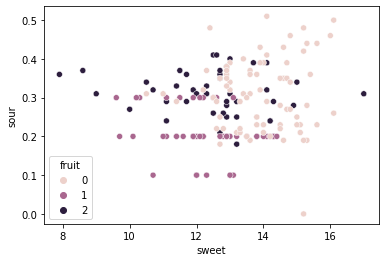

정확도 = 0.9
예측: 0  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 1  정답: 1
예측: 1  정답: 1
예측: 1  정답: 1
예측: 0  정답: 0
예측: 0  정답: 0
예측: 0  정답: 0


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 데이터를 가져오기
df = pd.read_excel('사과배복숭아-학습.xlsx')

# 모든 결측치 값을 0으로 대체
df.isna().sum()
df.fillna(0, inplace=True)
df.isna().sum()

#문자로 되어있는 fruit(과일 종류) 칼럼의 값을 수치값으로 변경
df['fruit'].value_counts()
df.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)

#과일 종류별 평균값 확인
df.groupby('fruit').mean()
#그래프 그리기
sns.scatterplot(data=df, x='weight', y='width', hue='fruit') 
plt.show()
sns.scatterplot(data=df, x='sweet', y='sour', hue='fruit') 
plt.show()

#모델 생성 및 학습
x_train = df.iloc[:, 1:]  # 학습 데이터의 속성값
y_train = df.iloc[:,0]    # 학습 데이터의 정답

#의사 결정트리 알고리즘 모델 객체를 생성
tr_model = DecisionTreeClassifier(random_state=0)
# 학습 데이터를 전달하여 머신러닝모델 완성
tr_model.fit(x_train, y_train)

# 테스트용 데이터 읽어오기
df_test = pd.read_excel('사과배복숭아-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)

# 테스트 데이터
x_test =  df_test.iloc[:, 1:]   # 테스트 데이터의 속성값
y_test =  df_test.iloc[:,0]     # 테스트 데이터의 정답
#생성한 모델을 사용해서 테스트 데이터의 속성값을 이용해 예측값 산출
tr_prd = tr_model.predict(x_test)

# 예측값과 테스트 데이터의 정답을 비교해서 정확도 계산
print('정확도 =',accuracy_score(y_test, tr_prd))
# 에측값과 테스트 데이터의 정답을 동시 출력해서 비교
for i in range(len(y_test)):
    print('예측:',tr_prd[i], ' 정답:',y_test.iloc[i])

# 2. K최근접 이웃(KNN) 알고리즘
### 데이터 전처리

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 데이터를 가져오기
df = pd.read_excel('사과배복숭아-학습.xlsx')

# 모든 결측치 값을 0으로 대체
df.fillna(0, inplace=True)

#문자로 되어있는 fruit(과일 종류) 칼럼의 값을 수치값으로 변경
df.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)
df

,fruit,weight,height,width,hardness,sweet,sour,color
0,2,310.7,76.2,86.3,45.2,12.7,0.35,60.8
1,2,265.9,74.5,81.8,29.5,14.2,0.24,61.0
2,2,407.5,82.6,90.1,34.1,14.3,0.29,68.2
3,2,314.6,74.5,86.1,22.1,14.9,0.28,62.1
4,2,310.7,77.5,85.7,31.1,13.0,0.40,64.6
...,...,...,...,...,...,...,...,...
163,0,221.3,73.2,80.0,55.8,10.5,0.31,43.6
164,0,252.2,71.3,84.3,34.5,13.4,0.40,42.6
165,0,284.3,78.2,88.0,36.2,13.6,0.36,44.8
166,0,314.3,77.3,91.1,34.1,12.9,0.35,45.7


### 모델 생성 및 학습

In [15]:
# 머신 러닝 학습
from sklearn.neighbors import KNeighborsClassifier

x_train = df.iloc[:, 1:]  
y_train = df.iloc[:,0] 

kn_model = KNeighborsClassifier(n_neighbors=5)  #최근접 이웃의 개수를 5개로 지정 (이웃 개수는 홀수로 지정해야 함.)
kn_model.fit(x_train, y_train)

KNeighborsClassifier()

### 모델 평가

In [16]:
#테스트 데이터 저장
df_test = pd.read_excel('사과배복숭아-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)
df_test

,fruit,weight,height,width,hardness,sweet,sour,color
0,2,400.5,82.6,90.1,32.1,15.3,0.29,68.2
1,2,310.6,73.5,80.1,20.1,15.0,0.28,62.1
2,2,340.0,75.0,86.7,20.5,14.1,0.32,58.4
3,2,330.0,78.8,85.0,41.5,13.0,0.31,58.6
4,1,680.0,100.0,111.6,36.8,12.0,0.10,0.0
5,1,640.0,99.0,96.3,30.1,12.0,0.20,0.0
6,1,599.6,104.1,86.7,31.5,10.1,0.20,0.0
7,0,319.0,87.0,89.2,57.7,13.3,0.21,56.1
8,0,350.0,89.0,91.8,35.0,13.6,0.31,57.8
9,0,270.0,75.0,85.0,37.0,13.3,0.22,55.6


In [17]:
#예측하기
x_test =  df_test.iloc[:, 1:]   
y_test =  df_test.iloc[:,0]     

kn_prd = kn_model.predict(x_test)
kn_prd

array([0, 2, 2, 2, 1, 1, 1, 0, 2, 0], dtype=int64)

In [18]:
#평가하기
from sklearn.metrics import accuracy_score

print('정확도 =',accuracy_score(y_test, kn_prd))
for i in range(len(y_test)):
    print('예측:',kn_prd[i], ' 정답:', y_test.iloc[i])

정확도 = 0.8
예측: 0  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 1  정답: 1
예측: 1  정답: 1
예측: 1  정답: 1
예측: 0  정답: 0
예측: 2  정답: 0
예측: 0  정답: 0


In [19]:
# 모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# 데이터를 가져오기
df = pd.read_excel('사과배복숭아-학습.xlsx')

# 모든 결측치 값을 0으로 대체
df.fillna(0, inplace=True)

#문자로 되어있는 fruit(과일 종류) 칼럼의 값을 수치값으로 변경
df.replace({'fruit':{ '사과':0, '배':1, '복숭아':2}}, inplace=True)

#모델 생성 및 학습
x_train = df.iloc[:, 1:]  # 학습 데이터의 속성값
y_train = df.iloc[:,0]    # 학습 데이터의 정답

#모델 객체를 생성(최근접 이웃의 개수를 5개로 지정.)
kn_model = KNeighborsClassifier(n_neighbors=5)  
# 학습 데이터를 전달하여 머신러닝모델 완성
kn_model.fit(x_train, y_train)

# 테스트용 데이터 읽어오기
df_test = pd.read_excel('사과배복숭아-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)

# 테스트 데이터
x_test =  df_test.iloc[:, 1:]   # 테스트 데이터의 속성값
y_test =  df_test.iloc[:,0]     # 테스트 데이터의 정답

#생성한 모델을 사용해서 테스트 데이터의 속성값을 이용해 예측값 산출
kn_prd = kn_model.predict(x_test)

# 예측값과 테스트 데이터의 정답을 비교해서 정확도 계산
print('정확도 =',accuracy_score(y_test, kn_prd))

# 에측값과 테스트 데이터의 정답을 동시 출력해서 비교
for i in range(len(y_test)):
    print('예측:',kn_prd[i], ' 정답:', y_test.iloc[i])


정확도 = 0.8
예측: 0  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 2  정답: 2
예측: 1  정답: 1
예측: 1  정답: 1
예측: 1  정답: 1
예측: 0  정답: 0
예측: 2  정답: 0
예측: 0  정답: 0


# 4.분류 모델의 평가 및 검증 
### 1. 정확도(Accuracy)
참, 거짓을 정확하게 맞춘 비율 <br>
예측 결과가 정답과 같은 데이터 수  /  전체 예측 데이터의 수

### 2.재현율(Recall)
실체 참인 데이터 중에서 모델이 참이라고 예측한 비율<br>
실제 정답이 참인 것 중에서 예측 결과가 참인 데이터의 수 / 실제 정답이 참인 데이터의 수

### 3. 정밀도(Precision)
참이라고 예측한 데이터 중에서 실제로 참인 데이터의 비율 <br>
예측 결과가 참인 것 중에서 실제 정답이 참인 데이터의 수 / 예측 결과가 참인 데이터의 수

In [20]:
# 모듈 import
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

# 데이터를 가져오기
df = pd.read_excel('사과배복숭아-학습.xlsx')
df.fillna(0, inplace=True)
df.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)
df_test = pd.read_excel('사과배복숭아-테스트.xlsx')
df_test.fillna(0, inplace=True)
df_test.replace({'fruit':{'사과':0, '배':1, '복숭아':2}}, inplace=True)

x_train = df.iloc[:, 1:]  # 학습 데이터의 속성값
y_train = df.iloc[:,0]    # 학습 데이터의 정답
x_test =  df_test.iloc[:, 1:]   # 테스트 데이터의 속성값
y_test =  df_test.iloc[:,0]     # 테스트 데이터의 정답

#의사 결정트리 알고리즘 모델 
tr_model = DecisionTreeClassifier(random_state=0)
tr_model.fit(x_train, y_train)
tr_prd = tr_model.predict(x_test)

# K 최근접 이웃 알고리즘 모델 
kn_model = KNeighborsClassifier(n_neighbors=5)  
kn_model.fit(x_train, y_train)
kn_prd = kn_model.predict(x_test)

# 랜덤 포레스트 알고리즘 모델
rf_model=RandomForestClassifier(n_estimators=7)
rf_model.fit(x_train, y_train)
rf_prd = rf_model.predict(x_test)

In [21]:
from sklearn.metrics import accuracy_score, recall_score, precision_score

print("==의사결정 트리 모델==")
print('정확도:', accuracy_score(y_test, tr_prd ))
print('재현율:', recall_score(y_test, tr_prd, average=None))  
print('정밀도:', precision_score(y_test, tr_prd, average=None))

print("==K 최근접 이웃 모델==")
print('정확도:', accuracy_score(y_test, kn_prd ))
print('재현율:', recall_score(y_test, kn_prd, average=None))  
print('정밀도:', precision_score(y_test, kn_prd, average=None))

print("==랜덤 포레스트 모델==")
print('정확도:', accuracy_score(y_test, rf_prd ))
print('재현율:', recall_score(y_test, rf_prd, average=None))  
print('정밀도:', precision_score(y_test, rf_prd, average=None))

==의사결정 트리 모델==
정확도: 0.9
재현율: [1.   1.   0.75]
정밀도: [0.75 1.   1.  ]
==K 최근접 이웃 모델==
정확도: 0.8
재현율: [0.66666667 1.         0.75      ]
정밀도: [0.66666667 1.         0.75      ]
==랜덤 포레스트 모델==
정확도: 0.8
재현율: [0.66666667 1.         0.75      ]
정밀도: [0.66666667 1.         0.75      ]
